In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(12,6)

In [4]:
# load dataset
DATA = Path("../data/processed")

fund_master = pd.read_csv(DATA/"01_fund_master_cleaned.csv")
nav = pd.read_csv(DATA/"02_nav_history_cleaned.csv")
aum = pd.read_csv(DATA/"03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv(DATA/"04_monthly_sip_inflows_cleaned.csv")
category = pd.read_csv(DATA/"05_category_inflows_cleaned.csv")
folio = pd.read_csv(DATA/"06_industry_folio_count_cleaned.csv")
performance = pd.read_csv(DATA/"07_scheme_performance_cleaned.csv")
transactions = pd.read_csv(DATA/"08_investor_transactions_cleaned.csv")
holdings = pd.read_csv(DATA/"09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv(DATA/"10_benchmark_indices_cleaned.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [ ]:
# convert date in datetime format

In [5]:
nav["date"] = pd.to_datetime(nav["date"])
aum["date"] = pd.to_datetime(aum["date"])
sip["month"] = pd.to_datetime(sip["month"])
category["month"] = pd.to_datetime(category["month"])
folio["month"] = pd.to_datetime(folio["month"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [ ]:
# merge scheme names

In [6]:
nav = nav.merge(
    fund_master[["amfi_code","scheme_name"]],
    on="amfi_code"
)

In [7]:
# calculate daily returns

return = nav_today / nav_yesterday -1

In [8]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].pct_change()
)

In [9]:
# check distribution

nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

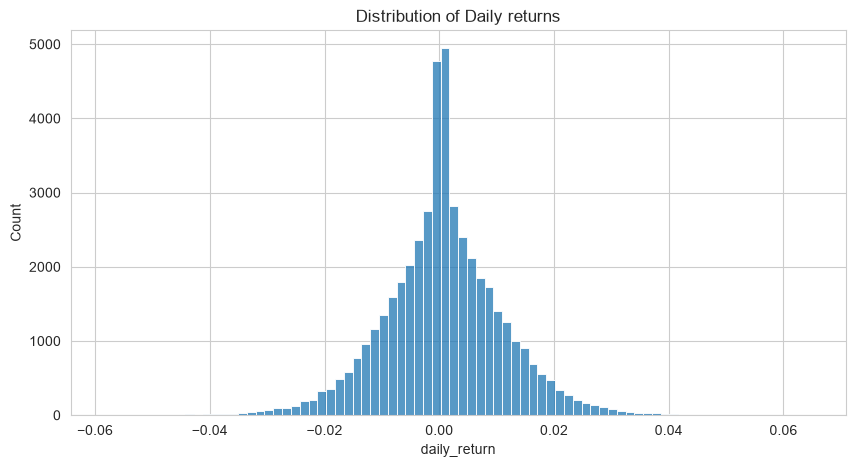

In [10]:
# histogram

plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna() , bins = 80
)

plt.title("Distribution of Daily returns")

plt.show()

In [11]:
# CAGR Calculation

In [12]:
def CAGR(start,end,years):

    return (end/start)**(1/years)-1

In [13]:
results=[]

for code in nav.amfi_code.unique():

    df=nav[nav.amfi_code==code]

    start=df.iloc[0]["nav"]

    end=df.iloc[-1]["nav"]

    years=(df.date.max()-df.date.min()).days/365

    cagr=CAGR(start,end,years)

    results.append([code,cagr])

cagr_df=pd.DataFrame(
    results,
    columns=["amfi_code","CAGR"]
)

In [14]:
# Calculate 1-Year, 3-Year and 5-Year CAGR

In [15]:
from dateutil.relativedelta import relativedelta

latest_date = nav["date"].max()

periods = {
    "1Y": 1,
    "3Y": 3,
    "5Y": 5
}

cagr_table = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code].sort_values("date")

    latest_nav = fund.iloc[-1]["nav"]

    row = {"amfi_code": code}

    for label, yrs in periods.items():

        target_date = latest_date - relativedelta(years=yrs)

        past = fund[fund["date"] >= target_date]

        if len(past) > 0:

            start_nav = past.iloc[0]["nav"]

            years = yrs

            row[f"CAGR_{label}"] = (latest_nav/start_nav)**(1/years)-1

        else:

            row[f"CAGR_{label}"] = np.nan

    cagr_table.append(row)

cagr_table = pd.DataFrame(cagr_table)

In [16]:
# Sharpe Ratio

In [17]:
# Risk-free rate
RF = 0.065

 <b>Fromula<b>
    <P>Sharpe=(Rp-Rf)/Std × √252<P>

In [18]:
sharpe=[]

for code in nav.amfi_code.unique():

    r = nav[
        nav.amfi_code==code
    ]["daily_return"].dropna()

    annual_return=r.mean()*252

    annual_std=r.std()*np.sqrt(252)

    s=(annual_return-RF)/annual_std

    sharpe.append([code,s])

sharpe=pd.DataFrame(
    sharpe,
    columns=["amfi_code","Sharpe"]
)

In [19]:
# Sortino Ratio

In [20]:
sortino=[]

for code in nav.amfi_code.unique():

    r=nav[
        nav.amfi_code==code
    ]["daily_return"].dropna()

    downside=r[r<0]

    downside_std=downside.std()*np.sqrt(252)

    annual=r.mean()*252

    ratio=(annual-RF)/downside_std

    sortino.append([code,ratio])

sortino=pd.DataFrame(
    sortino,
    columns=["amfi_code","Sortino"]
)

In [21]:
# Alpha and Beta

Benchmark

In [44]:
nifty = benchmark[
    benchmark.index_name=="NIFTY100"
].copy()

nifty=nifty.sort_values("date")

nifty["benchmark_return"]=(
    nifty["close_value"].pct_change()
)

Regression

In [27]:
alpha_beta=[]

for code in nav.amfi_code.unique():

    fund=nav[
        nav.amfi_code==code
    ][["date","daily_return"]]

    merged=fund.merge(
        nifty[
            ["date","benchmark_return"]
        ],
        on="date"
    ).dropna()

    slope,intercept,r,p,se = linregress(

        merged["benchmark_return"],

        merged["daily_return"]

    )

    alpha=intercept*252

    beta=slope

    alpha_beta.append([

        code,

        alpha,

        beta

    ])

alpha_beta=pd.DataFrame(

    alpha_beta,

    columns=[

        "amfi_code",

        "Alpha",

        "Beta"

    ]

)

In [29]:
# save

In [28]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [31]:
# Maximum Drawdown

In [30]:
drawdown=[]

for code in nav.amfi_code.unique():

    df=nav[
        nav.amfi_code==code
    ].copy()

    df["running_max"]=df.nav.cummax()

    df["drawdown"]=(
        df.nav/
        df.running_max
    )-1

    mdd=df.drawdown.min()

    drawdown.append([

        code,

        mdd

    ])

drawdown=pd.DataFrame(

    drawdown,

    columns=[

        "amfi_code",

        "Max_Drawdown"

    ]

)

In [32]:
# Fund Scorecard

Merge everything

In [33]:
score = cagr_table.merge(sharpe,on="amfi_code")
score = score.merge(alpha_beta,on="amfi_code")
score = score.merge(drawdown,on="amfi_code")
score = score.merge(
    performance[
        ["amfi_code","expense_ratio_pct"]
    ],
    on="amfi_code"
)

Ranking

In [34]:
score["ReturnRank"] = score["CAGR_3Y"].rank(ascending=False)

score["SharpeRank"] = score["Sharpe"].rank(ascending=False)

score["AlphaRank"] = score["Alpha"].rank(ascending=False)

score["ExpenseRank"] = score["expense_ratio_pct"].rank()

score["DrawdownRank"] = score["Max_Drawdown"].rank(ascending=False)

Composite Score

In [35]:
score["Score"]=(

30*score.ReturnRank+

25*score.SharpeRank+

20*score.AlphaRank+

15*score.ExpenseRank+

10*score.DrawdownRank

)/100

Normalize to 100

In [36]:
score["FundScore"]=100*(
score.Score-score.Score.min()
)/(
score.Score.max()-score.Score.min()
)

In [37]:
# save

In [38]:
score.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [39]:
#Benchmark Comparison

Select top 5 funds

In [40]:
top5 = score.nsmallest(5,"ReturnRank")["amfi_code"]

In [41]:
top5 = score.nsmallest(5,"ReturnRank")["amfi_code"]

In [42]:
# Tracking Error

In [43]:
tracking=[]

for code in top5:

    fund=nav[
        nav.amfi_code==code
    ][["date","daily_return"]]

    merged=fund.merge(

        nifty[
            ["date","benchmark_return"]
        ],

        on="date"

    ).dropna()

    te=np.std(

        merged.daily_return-

        merged.benchmark_return

    )*np.sqrt(252)

    tracking.append([

        code,

        te

    ])

tracking=pd.DataFrame(

tracking,

columns=[

"amfi_code",

"TrackingError"

]
)

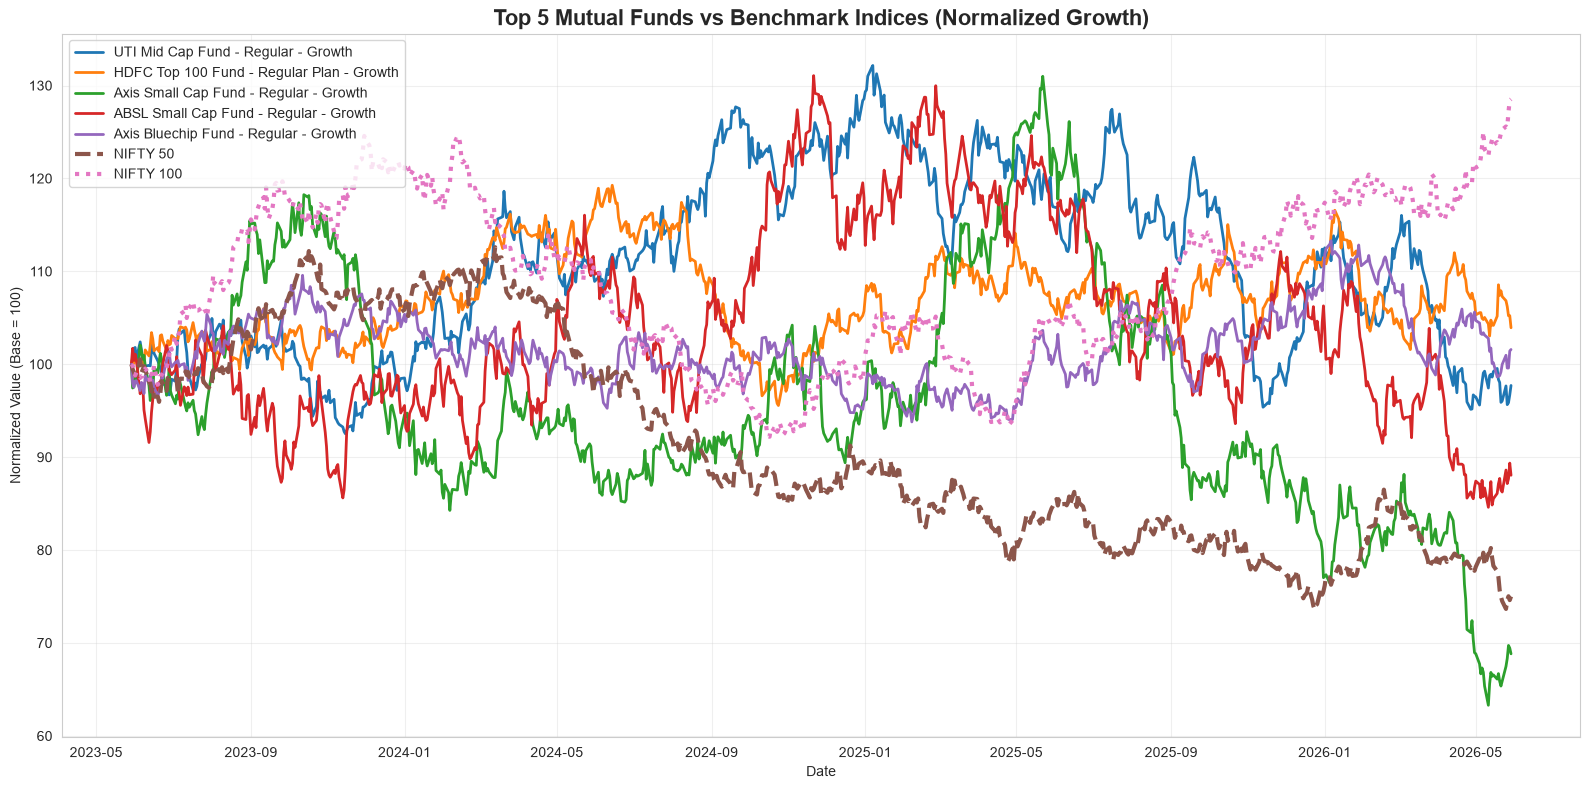

In [45]:
# ============================================
# Benchmark Comparison (Top 5 Funds vs NIFTY)
# ============================================

import matplotlib.pyplot as plt

# Select Top 5 Funds
top5 = score.sort_values("FundScore", ascending=False).head(5)["amfi_code"]

# Last 3 Years
end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

nav_last3 = nav[nav["date"] >= start_date].copy()

# Normalize Fund NAV
plt.figure(figsize=(16,8))

for code in top5:

    fund = nav_last3[nav_last3["amfi_code"] == code].copy()

    fund = fund.sort_values("date")

    fund["Normalized"] = (
        fund["nav"] /
        fund["nav"].iloc[0]
    ) * 100

    scheme = fund_master.loc[
        fund_master["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        fund["date"],
        fund["Normalized"],
        linewidth=2,
        label=scheme
    )

# --------------------------
# NIFTY 50
# --------------------------

nifty50 = benchmark[
    benchmark["index_name"]=="NIFTY50"
].copy()

nifty50 = nifty50[
    nifty50["date"]>=start_date
]

nifty50["Normalized"] = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0]
) * 100

plt.plot(
    nifty50["date"],
    nifty50["Normalized"],
    linestyle="--",
    linewidth=3,
    label="NIFTY 50"
)

# --------------------------
# NIFTY 100
# --------------------------

nifty100 = benchmark[
    benchmark["index_name"]=="NIFTY100"
].copy()

nifty100 = nifty100[
    nifty100["date"]>=start_date
]

nifty100["Normalized"] = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100["date"],
    nifty100["Normalized"],
    linestyle=":",
    linewidth=3,
    label="NIFTY 100"
)

plt.title(
    "Top 5 Mutual Funds vs Benchmark Indices (Normalized Growth)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")

plt.ylabel("Normalized Value (Base = 100)")

plt.legend(loc="upper left")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()